# Aprendizaje Profundo
## Tarea 3 - Redes Basadas en Atención
### Eduardo García


### Reconocimiento de comandos de voz
Entrena una red neuronal basada en bloques Transformer para el reconocimiento de comandos de voz usados en el conjunto Speech Commands. Se deberá representar los comandos de voz mediante espectrogramas Mel, Mel-Log o MFCCs y procesar estos como una secuencia de vectores columna.  

## Bibliotecas

In [72]:
# Bibliotecas 図書館
import numpy as np
# import matplotlib
from matplotlib import pyplot as plt
from tqdm import tqdm, trange
import pandas as pd

import torch as th
from torch import nn

# Por reproducibilidad
th.manual_seed(42)
np.random.seed(42)

LOGDIR = './logs/'
DC     = 'cuda:0' if th.cuda.is_available() else 'cpu'
print(f'Device {DC}')

Device cpu


In [73]:
# audio
import librosa
import librosa.display

# redes audio
import torchaudio
import torchaudio.transforms as T


# redes neuronales
from torch.utils.data import DataLoader
from torchaudio.datasets import SPEECHCOMMANDS

# barras de progreso
from tqdm.auto import trange

# Files
import os

## Datos

In [74]:
DATADIR = './'
download = not os.path.isdir('./SpeechCommands')
ds = SPEECHCOMMANDS(DATADIR, download=download)

In [75]:
# Tamaño de lote
BATCH_SIZE = 64

# Audio Params
SECS = 1
SAMPLE_RATE = 16000

# FFT Params
N_FFT = 400
HOP_LENGHT = N_FFT//2

# SpeechCommands classes
CLASSES = (
    'backward', 'bed', 'bird', 'cat', 'dog',
    'down', 'eight', 'five', 'follow', 'forward',
    'four', 'go', 'happy', 'house', 'learn',
    'left', 'marvin', 'nine', 'no', 'off',
    'on', 'one', 'right', 'seven', 'sheila',
    'six', 'stop', 'three', 'tree', 'two',
    'up', 'visual', 'wow', 'yes', 'zero'
)

NUM_CLASSES = len(CLASSES)
CLASS_IDX = {c: i for i, c in enumerate(CLASSES)}
print(CLASS_IDX)

{'backward': 0, 'bed': 1, 'bird': 2, 'cat': 3, 'dog': 4, 'down': 5, 'eight': 6, 'five': 7, 'follow': 8, 'forward': 9, 'four': 10, 'go': 11, 'happy': 12, 'house': 13, 'learn': 14, 'left': 15, 'marvin': 16, 'nine': 17, 'no': 18, 'off': 19, 'on': 20, 'one': 21, 'right': 22, 'seven': 23, 'sheila': 24, 'six': 25, 'stop': 26, 'three': 27, 'tree': 28, 'two': 29, 'up': 30, 'visual': 31, 'wow': 32, 'yes': 33, 'zero': 34}


In [76]:

def identity(x):
  return x


def label2index(label):
  return CLASS_IDX[label]


class SPEECHCOMMANDS2(SPEECHCOMMANDS):

  def __init__(self, root, download=False, subset=None,
               waveform_tsfm=identity, label_tsfm=identity):
      
      super().__init__(root=root, download=download, subset=subset)
      self.time_mask = T.TimeMasking(time_mask_param=4000)
      self.waveform_tsfm = waveform_tsfm
      self.label_tsfm = label_tsfm
      
  def __getitem__(self, i):
    waveform, sample_rate, label, *_ = super().__getitem__(i)

    x = self.waveform_tsfm(waveform)
    y = self.label_tsfm(label)
    return x, y, label, sample_rate

In [77]:
class WaveformPadTruncate(nn.Module):

  def __init__(self, secs=SECS, sample_rate=SAMPLE_RATE):
    super().__init__()
    self.samples = secs * sample_rate

  def forward(self, waveform):
    samples = waveform.shape[1]

    if samples < self.samples:
      difference = self.samples - samples
      padding = th.zeros(1, difference)
      waveform = th.cat([waveform, padding], 1)

    elif samples > self.samples:
      start = np.random.randint(0, waveform.shape[1] - self.samples)
      # Devuelve un nuevo tensor que es una versión reducida del tensor de entrada.
      waveform = waveform.narrow(1, start, self.samples) # (dimension, start, length)

    return waveform


In [78]:
class RandomSilence(nn.Module):
  def __init__(self, ratio=.3):
    super().__init__()
    self.ratio = ratio

  def forward(self, waveform):
    samples = waveform.shape[1]
    # print(samples)
    silence_size = int(samples * self.ratio)
    # print(f'{silence_size = }')
    start = np.random.randint(0, samples - silence_size)
    # print(f'{start = }')
    waveform[:, start:start+silence_size] = 0.0

    return waveform
    

In [79]:
data_aug = nn.Sequential(
  WaveformPadTruncate(),
  RandomSilence(),
  T.MFCC()
)

In [80]:
# creamos un Dataset
ds = SPEECHCOMMANDS2(
    # directorio de datos
    root=DATADIR,
    # transformación de la forma de onda
    waveform_tsfm=data_aug,
    #conjunto de entrenamiento
    subset="training",
    # transformación de etiqueta
    label_tsfm=label2index,
)

# creamos un DataLoader
dl_ent = DataLoader(
    # conjunto
    ds,
    # tamaño del lote
    batch_size=BATCH_SIZE,
    # desordenar
    shuffle=True)


# creamos un Dataset
ds_val = SPEECHCOMMANDS2(
    root=DATADIR,
    # transformación de la forma de onda
    waveform_tsfm=data_aug,
    #conjunto de validacion
    subset="validation",
    # transformación de etiqueta
    label_tsfm=label2index,
)

# creamos un DataLoader
dl_val = DataLoader(
    # conjunto
    ds,
    # tamaño del lote
    batch_size=BATCH_SIZE,
    # desordenar
    shuffle=True)

In [81]:
# desplegamos un lote de ejemplos
x, y, labels, sr = next(iter(dl_ent))
print(f'x shape={x.shape} dtype={x.dtype}')
print(f'y shape={y.shape} dtype={y.dtype}')
print(f'{labels = }, {sr=}')

x shape=torch.Size([64, 1, 40, 81]) dtype=torch.float32
y shape=torch.Size([64]) dtype=torch.int64
labels = ('on', 'up', 'eight', 'yes', 'no', 'up', 'yes', 'house', 'seven', 'left', 'left', 'six', 'go', 'on', 'three', 'forward', 'go', 'yes', 'seven', 'house', 'six', 'five', 'eight', 'go', 'three', 'tree', 'sheila', 'up', 'backward', 'right', 'happy', 'on', 'visual', 'backward', 'seven', 'off', 'four', 'visual', 'three', 'off', 'eight', 'bed', 'on', 'up', 'two', 'left', 'seven', 'up', 'yes', 'stop', 'sheila', 'cat', 'up', 'house', 'two', 'left', 'three', 'eight', 'nine', 'down', 'bird', 'tree', 'on', 'seven'), sr=tensor([16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000,
        16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000,
        16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000,
        16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000,
        16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 1600

In [87]:
def plot_mfcc(mfcc, sample_rate, title="MFCC"):
    if isinstance(mfcc, th.Tensor):
        mfcc = mfcc.numpy()

    # Plot the MFCCs
    plt.figure(figsize=(10, 4))
    plt.imshow(mfcc, aspect="auto", origin="lower", cmap="plasma")
    plt.colorbar(format="%+2.0f dB")
    plt.title(title)
    plt.xlabel("Time (frames)")
    plt.ylabel("MFCC Coefficients")
    plt.tight_layout()
    plt.show()

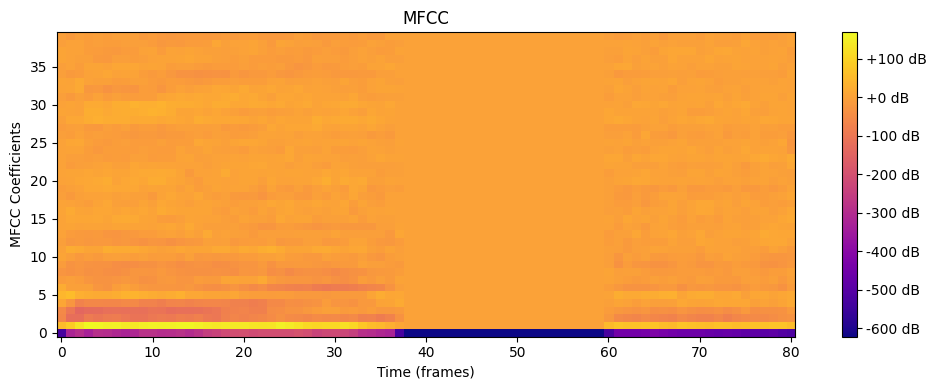

In [88]:
plot_mfcc(x[0].reshape(40, 81, 1), SAMPLE_RATE)

## Modelo

In [89]:
class ProductoPuntoEscalado(nn.Module):
  def __init__(self,
               p_dropout = 0.0,
               masc = False):
    super(ProductoPuntoEscalado, self).__init__()
    self.masc = masc
    self.dropout = nn.Dropout(p_dropout)

  def forward(self, Q, K, V):
    # Obtenemos dimensiones
    m, n_cabezas, l, d_k = K.shape
    d_v = V.shape[-1]

    # Cambiamos la forma: [m, n_cabezas, l, d_k] -> [m * n_cabezas, l, d_k]
    Q = Q.reshape(m * n_cabezas, l, d_k)
    K = K.reshape(m * n_cabezas, l, d_k)
    V = V.reshape(m * n_cabezas, l, d_v)

    # Q y K tienen forma [m * n_cabezas, l, d_k],
    # por lo que se transponen las dos últimas dimensiones de K
    # QK: [m * n_cabezas, l, l]
    QK = th.bmm(Q, K.transpose(1, 2))

    # se escalan los valores QK
    QK_esc = QK / th.math.sqrt(d_k)

    if self.masc:
      # Creamos una matriz triangular superior binaria (excluyendo la diagonal)
      masc = th.triu(th.ones((l, l), dtype = th.bool, device = Q.device),
                    diagonal = 1)
      # Ponemos los valores de QK_esc en los que la máscara sea 1 a -inf
      QK_esc = QK_esc.masked_fill_(masc, -th.inf)

    # mapas de atención: [m * n_cabezas, l, l] -> [m * n_cabezas, l, l]
    alfas = nn.functional.softmax(QK_esc, dim=-1)
    alfas = self.dropout(alfas) # Se agrega dropout de acuerdo al codigo de nanoGPT

    # vectores de salida y
    # alfas: [m * n_cabezas, l, l], V: [m * n_cabezas, l, d_v]
    # Y: [m * n_cabezas, l, d_v]
    Y = th.bmm(alfas, V)

    # Cambiamos la forma: [m * n_cabezas, l, d_v] -> [m, n_cabezas, l, d_v]
    Y = Y.reshape(m, n_cabezas, l, d_v)

    # Cambiamos la forma: [m * n_cabezas, l, l] -> [m, n_cabezas, l, l]
    alfas = alfas.reshape(m, n_cabezas, l, l)

    return Y, alfas


class AtencionMulticabeza(nn.Module):
  def __init__(self,
               d_modelo,
               n_cabezas,
               p_dropout = 0.0,
               masc = False):
    super(AtencionMulticabeza, self).__init__()

    self.n_cabezas = n_cabezas
    self.d_modelo = d_modelo

    self.d_cabezas = self.d_modelo // self.n_cabezas

    self.ppe = ProductoPuntoEscalado(p_dropout=p_dropout, masc = masc)
    self.proy_Q = nn.Linear(self.d_modelo, self.d_modelo, bias = False)
    self.proy_K = nn.Linear(self.d_modelo, self.d_modelo, bias = False)
    self.proy_V = nn.Linear(self.d_modelo, self.d_modelo, bias = False)
    self.proy_sal = nn.Linear(self.d_modelo, self.d_modelo)

  def forward(self, x):
    m, l, d_modelo = x.shape

    # Cambiamos la forma del tensor x
    # [m, l, d_modelo] -> [m * l, d_modelo]
    x = x.reshape(m * l, d_modelo)

    # Proyectamos vectores en x a Q, K, V
    # [m * l, d_modelo] -> [m * l, d_modelo]
    Q = self.proy_Q(x)
    K = self.proy_K(x)
    V = self.proy_V(x)

    # Cambiamos la forma: [m * l, d_modelo] -> [m, l, n_cabezas, d_k]
    # d_k = d_v = self.d_modelo // self.n_cabezas
    Q = Q.reshape(m, l, self.n_cabezas, self.d_cabezas)
    K = K.reshape(m, l, self.n_cabezas, self.d_cabezas)
    V = V.reshape(m, l, self.n_cabezas, self.d_cabezas)

    # Transponemos el eje de las cabezas a la segunda posición del tensor y
    # creamos copia (con .contiguous()) para que esté almacenado en memoria de
    # forma contigua (.transpose() hace que ya no sea así).
    # [m, l, n_cabezas, d_k] -> [m, n_cabezas, l, d_k]
    Q = Q.transpose(1, 2).contiguous()
    K = K.transpose(1, 2).contiguous()
    V = V.transpose(1, 2).contiguous()

    # Calculamos el producto punto escalado con Q, K y V
    # Q, K: [m, n_cabezas, l, d_k], V:[m, n_cabezas, l, d_v]
    # Y: [m, n_cabezas, l, d_v], alfas: [m, n_cabezas, l, l]
    Y, alfas = self.ppe(Q, K, V)

    # Transponermos el eje de cabezas a la penúltima posición:
    # [m, n_cabezas, l, d_k] -> [m, l, n_cabezas, d_k]
    Y = Y.transpose(1, 2).contiguous()

    # Concatemanos los vectores de todas las cabezas en un solo vector
    # [m, l, n_cabezas, d_k] -> [m * l, d_modelo]
    # d_modelo = n_cabezas * d_k
    Y = Y.reshape(m * l, self.d_modelo)

    # Proyectamos la vectores concatenados para obtener la salida
    # [m * l, d_modelo] -> [m * l, d_modelo]
    Y = self.proy_sal(Y)

    # Concatemanos los vectores de todas las cabezas en un solo vector
    # [m * l, d_modelo] -> [m, l, d_modelo]
    Y = Y.reshape(m, l, self.d_modelo)

    return Y, alfas

class RedDensaPosicion(nn.Module):
  def __init__(self,
               d_modelo,
               d_ff):
    super(RedDensaPosicion, self).__init__()
    self.d_modelo = d_modelo
    self.d_ff = self.d_ff = d_ff if d_ff else 4*d_modelo
    self.densa1 = nn.Linear(self.d_modelo, self.d_ff)
    self.densa2 = nn.Linear(self.d_ff, self.d_modelo)

  def forward(self, x):
    m, l, d_modelo = x.shape

    # Cambiamos la forma: [m, l, d_modelo] -> [m * l, d_modelo]
    x = x.reshape(m * l, d_modelo)

    # Pasamos el tensor redimensionado por la red densa
    # [m * l, d_modelo] -> [m * l, d_modelo]
    x = self.densa1(x)
    x = nn.functional.gelu(x)
    x = self.densa2(x)

    # Lo regresamos a su forma original
    # [m * l, d_modelo] -> [m, l, d_modelo]
    x = x.reshape(m, l, d_modelo)

    return x

class BloqueTransformer(nn.Module):
  def __init__(self,
               d_modelo,
               n_cabezas,
               d_rdp=None,
               p_dropout = 0.1,
              masc = False):
    super(BloqueTransformer, self).__init__()
    self.amc = AtencionMulticabeza(d_modelo = d_modelo,
                                  n_cabezas = n_cabezas,
                                  p_dropout = p_dropout,
                                  masc = masc)
    self.norm1 = nn.LayerNorm(d_modelo)
    self.rp = RedDensaPosicion(d_modelo, d_rdp)
    self.norm2 = nn.LayerNorm(d_modelo)
    self.dropout1 = nn.Dropout(p_dropout)
    self.dropout2 = nn.Dropout(p_dropout)

  def forward(self, x):
    salidas_amc, alfas = self.amc(x)
    salidas_amc = self.dropout1(salidas_amc)
    salidas_amc = self.norm1(x + salidas_amc)

    salidas_rp = self.rp(salidas_amc)
    salidas_rp = self.dropout2(salidas_rp)

    return self.norm2(salidas_amc + salidas_rp)